# SPADE Pipeline Exploration Notebook

This notebook breaks down the entire SPADE pipeline into explorable cells:
- Data loading and visualization
- Synthetic anomaly generation (80/20 normal/synthetic split)
- Comparison: synthetic vs real test anomalies
- Training data preparation
- Model inference and heatmap visualization
- Patch-level label analysis


## 1. Setup and Imports


In [1]:
import sys
from pathlib import Path

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import yaml
import cv2
from torch.utils.data import DataLoader

from data.mvtec_dataset import MVTecDataset
from data.synthetic import cutpaste, crack_anomaly, mask_to_patch_labels, get_methods_for_category
from utils.heatmap import patches_to_heatmap, overlay_heatmap

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## 2. Load Configuration


In [2]:
# Load config
config_dir = Path.cwd().parent / "config"
with open(config_dir / "data.yaml") as f:
    data_cfg = yaml.safe_load(f)

category = data_cfg["dataset"]["category"]
root = data_cfg["dataset"]["root"]
image_size = data_cfg["dataset"]["image_size"]
synthetic_prob = data_cfg["synthetic"]["synthetic_prob"]

# Resolve relative paths relative to project root (parent of notebooks/)
project_root = Path.cwd().parent
if not Path(root).is_absolute():
    root = str(project_root / root)

print(f"Category: {category}")
print(f"Root: {root}")
print(f"Image size: {image_size}")
print(f"Synthetic probability: {synthetic_prob} (80% normal, 20% synthetic)")
print(f"Full path: {Path(root) / category / 'train' / 'good'}")


Category: bottle
Root: /home/owais/spade/datasets/mvtec_anomaly_detection
Image size: 224
Synthetic probability: 0.2 (80% normal, 20% synthetic)
Full path: /home/owais/spade/datasets/mvtec_anomaly_detection/bottle/train/good


## 3. Load Training Data (Normal Images)


In [3]:
# Load normal training images (no synthetic anomalies yet)
train_dataset_normal = MVTecDataset(
    root = "../datasets/mvtec_anomaly_detection",
    category=category,
    split="train",
    image_size=image_size,
    synthetic_method=None,  # No synthetic anomalies
    synthetic_prob=0.0,
)

print(f"Total normal training images: {len(train_dataset_normal)}")

Total normal training images: 209


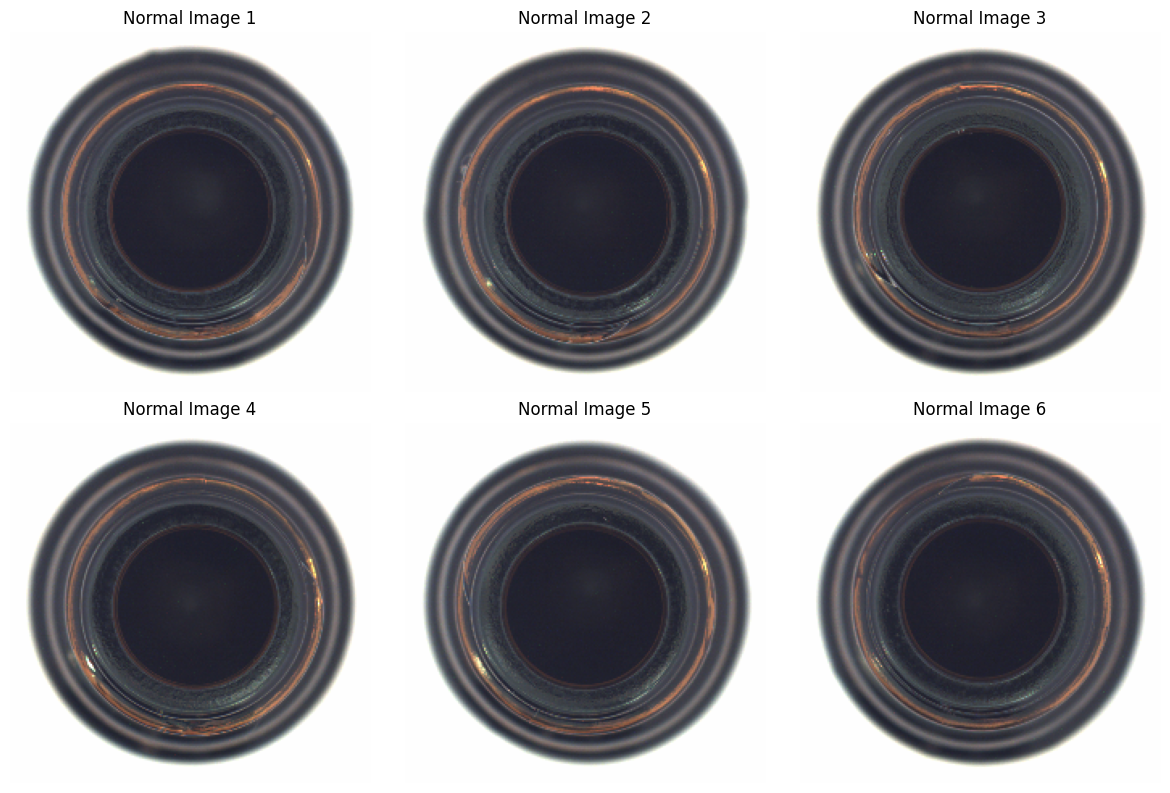

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i in range(min(6, len(train_dataset_normal))):
    sample = train_dataset_normal[i]
    image = sample["image"]
    
    # Convert tensor to numpy for visualization
    if isinstance(image, torch.Tensor):
        image_np = image.permute(1, 2, 0).cpu().numpy()
        # Denormalize for visualization (CLIP normalization stats)
        mean = np.array([0.48145466, 0.4578275, 0.40821073])
        std = np.array([0.26862954, 0.26130258, 0.27577711])
        image_np = image_np * std + mean
        image_np = np.clip(image_np, 0, 1)
    else:
        image_np = np.array(image)
    
    axes[i].imshow(image_np)
    axes[i].set_title(f"Normal Image {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 4. Synthetic Anomaly Generation Visualization


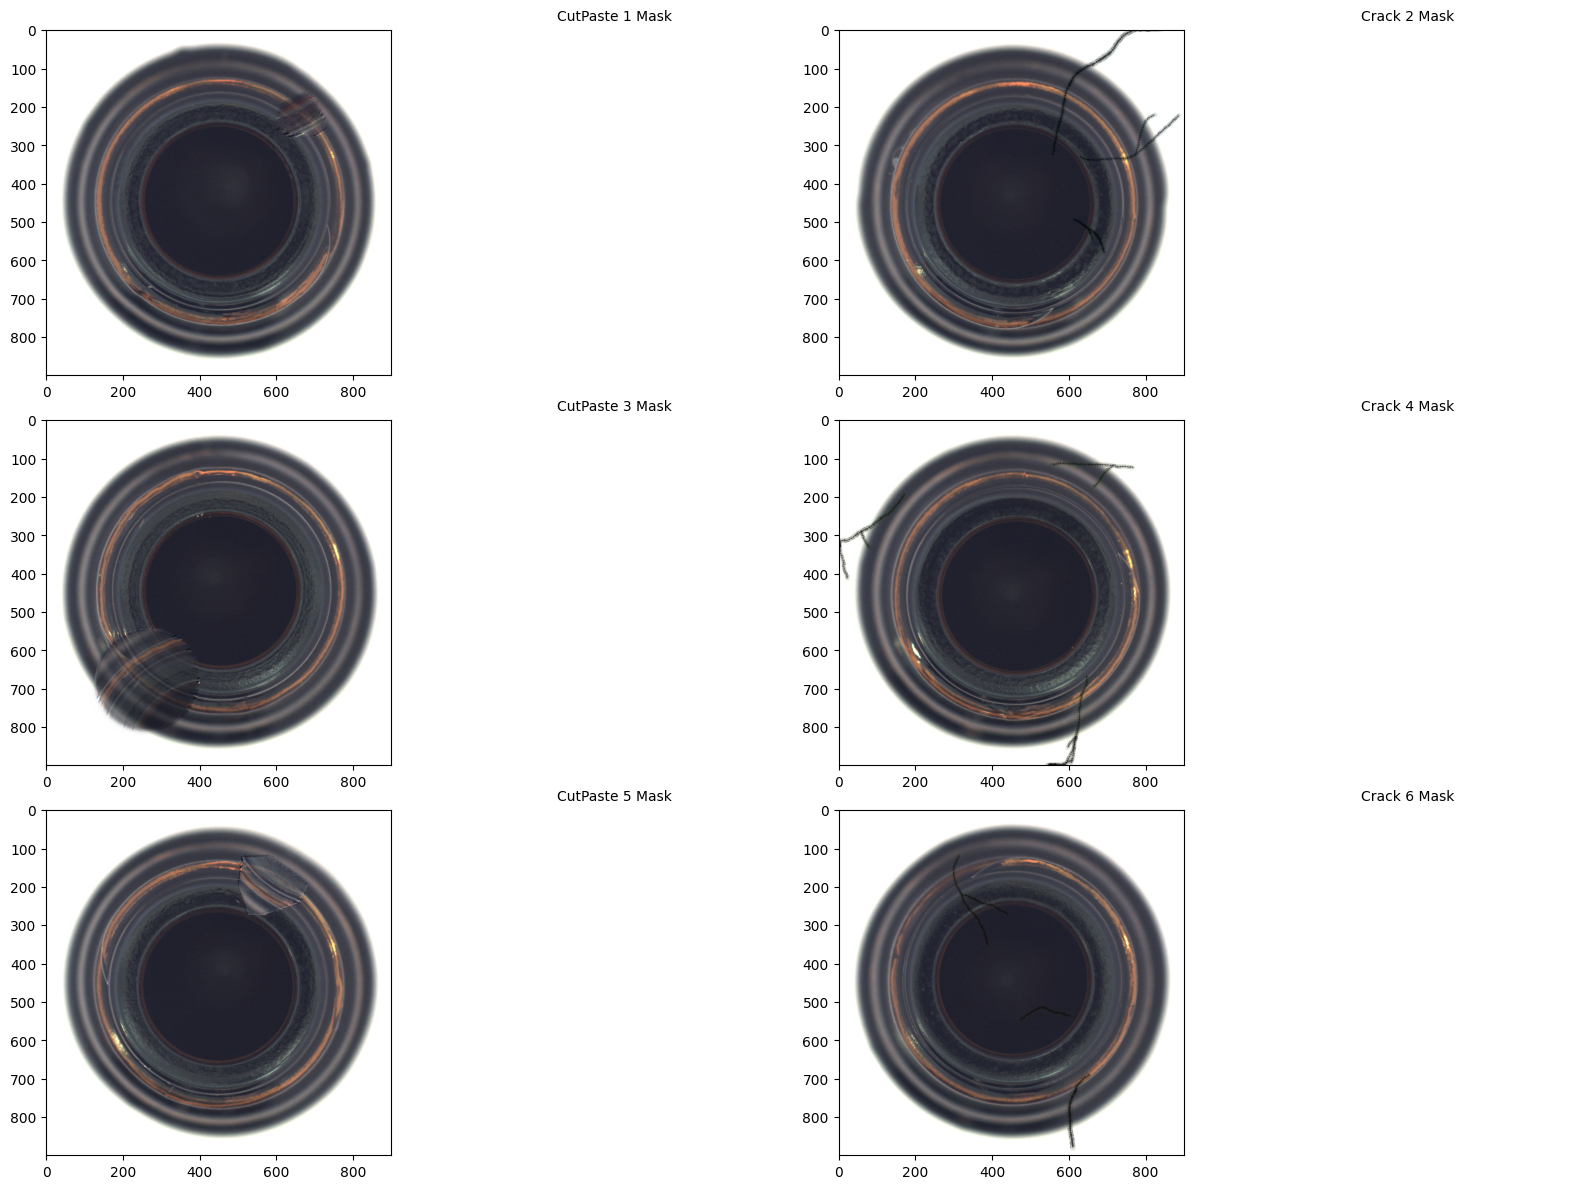

In [8]:
# Generate multiple synthetic anomalies on different normal images
num_samples = 6
synthetic_samples = []

for sample_idx in range(num_samples):
    # Load raw image for synthetic generation
    root_path = Path(root) / category / "train" / "good"
    image_files = sorted(list(root_path.glob("*.png")))
    raw_image = cv2.imread(str(image_files[sample_idx]))
    raw_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
    
    # Alternate between CutPaste and Crack
    if sample_idx % 2 == 0:
        aug_image, aug_mask = cutpaste(raw_image.copy())
        method_name = "CutPaste"
    else:
        aug_image, aug_mask = crack_anomaly(raw_image.copy())
        method_name = "Crack"
    
    synthetic_samples.append({
        "image": aug_image,
        "mask": aug_mask,
        "method": method_name
    })

# Visualize in 3x4 grid: each row shows (image, mask) pairs
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i in range(num_samples):
    sample = synthetic_samples[i]
    image = sample["image"]
    mask = sample["mask"]
    method = sample["method"]
    
    # Calculate row and column indices
    row = i // 2
    col_image = (i % 2) * 2
    col_mask = col_image + 1
    
    # Show image
    axes[row, col_image].imshow(image)
    axes[row, col_image].set_title(f"{method} {i+1}", fontsize=10)
    axes[row, col_image].axis("off")
    
    # Show mask
    axes[row, col_mask].imshow(mask, cmap="gray")
    axes[row, col_mask].set_title(f"{method} {i+1} Mask", fontsize=10)
    axes[row, col_mask].axis("off")

plt.tight_layout()
plt.show()


Found 6 synthetic anomaly samples


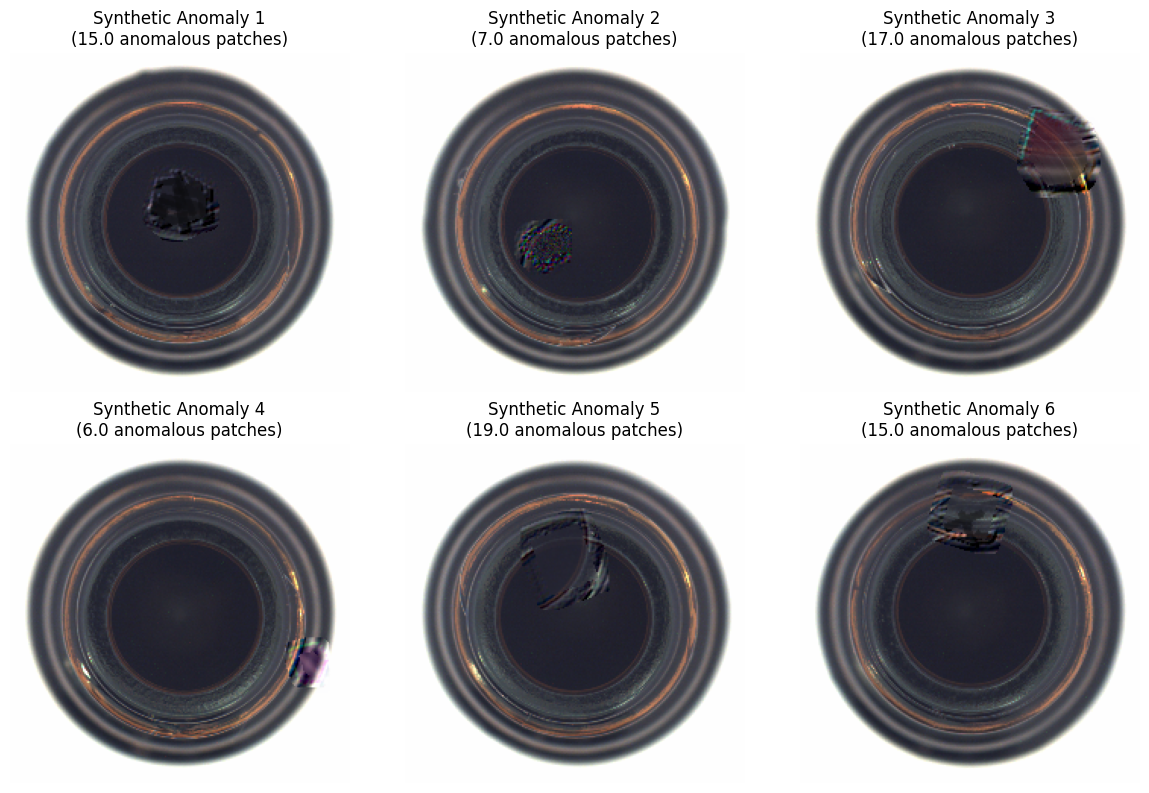

In [ ]:
# Visualize synthetic anomalies from dataset (with transforms applied) - same format as normal images
# Load training dataset with synthetic anomalies (100% synthetic for visualization)
available_methods = get_methods_for_category(category)
train_dataset_synthetic_viz = MVTecDataset(
    root=root,
    category=category,
    split="train",
    image_size=image_size,
    synthetic_method=available_methods[0] if available_methods else "cutpaste",
    synthetic_prob=1.0,  # 100% synthetic
)

# Collect synthetic anomaly samples
synthetic_samples_viz = []
max_iterations = min(100, len(train_dataset_synthetic_viz))
for i in range(max_iterations):
    sample = train_dataset_synthetic_viz[i]
    if sample["label"] == 1:  # Synthetic anomaly
        synthetic_samples_viz.append(sample)
    if len(synthetic_samples_viz) >= 6:
        break

print(f"Found {len(synthetic_samples_viz)} synthetic anomaly samples")

# Visualize in 2x3 grid (same format as normal images)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i in range(min(6, len(synthetic_samples_viz))):
    sample = synthetic_samples_viz[i]
    image = sample["image"]
    patch_labels = sample["patch_labels"]
    
    # Convert tensor to numpy for visualization (with denormalization)
    if isinstance(image, torch.Tensor):
        image_np = image.permute(1, 2, 0).cpu().numpy()
        # Denormalize for visualization (CLIP normalization stats)
        mean = np.array([0.48145466, 0.4578275, 0.40821073])
        std = np.array([0.26862954, 0.26130258, 0.27577711])
        image_np = image_np * std + mean
        image_np = np.clip(image_np, 0, 1)
    else:
        image_np = np.array(image)
    
    axes[i].imshow(image_np)
    num_anomaly_patches = patch_labels.sum().item()
    axes[i].set_title(f"Synthetic Anomaly {i+1}\n({num_anomaly_patches} anomalous patches)")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## 5. Patch-Level Label Generation


CutPaste 1: 22.0 anomalous patches out of 256 (expected 256 total patches)


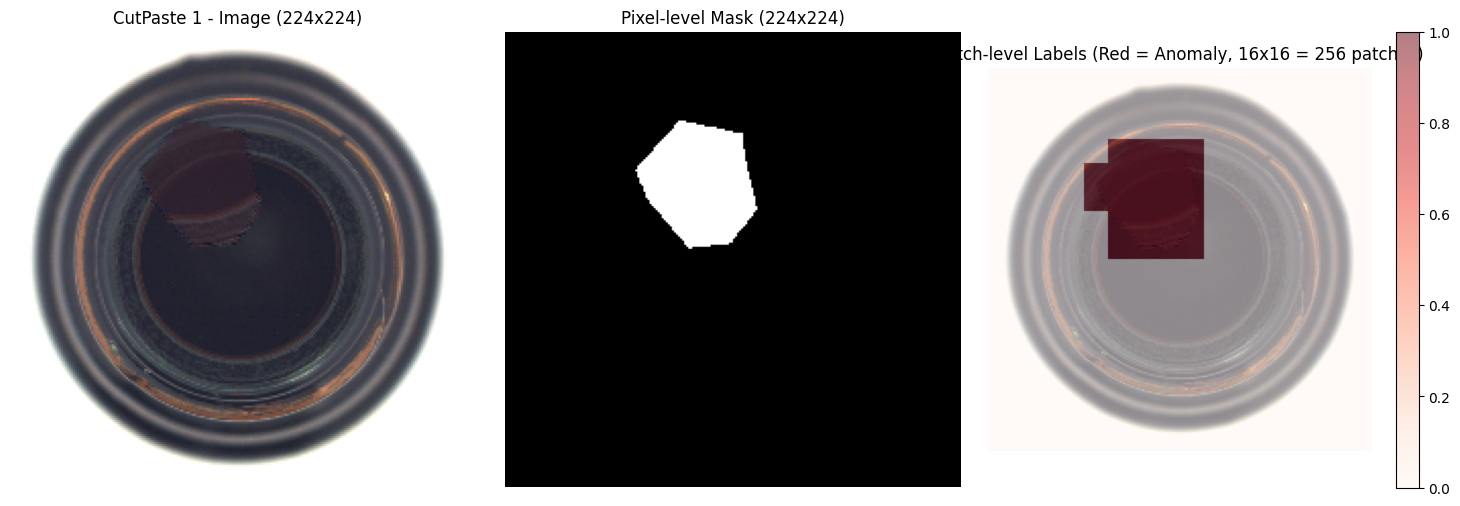

Crack 2: 24.0 anomalous patches out of 256 (expected 256 total patches)


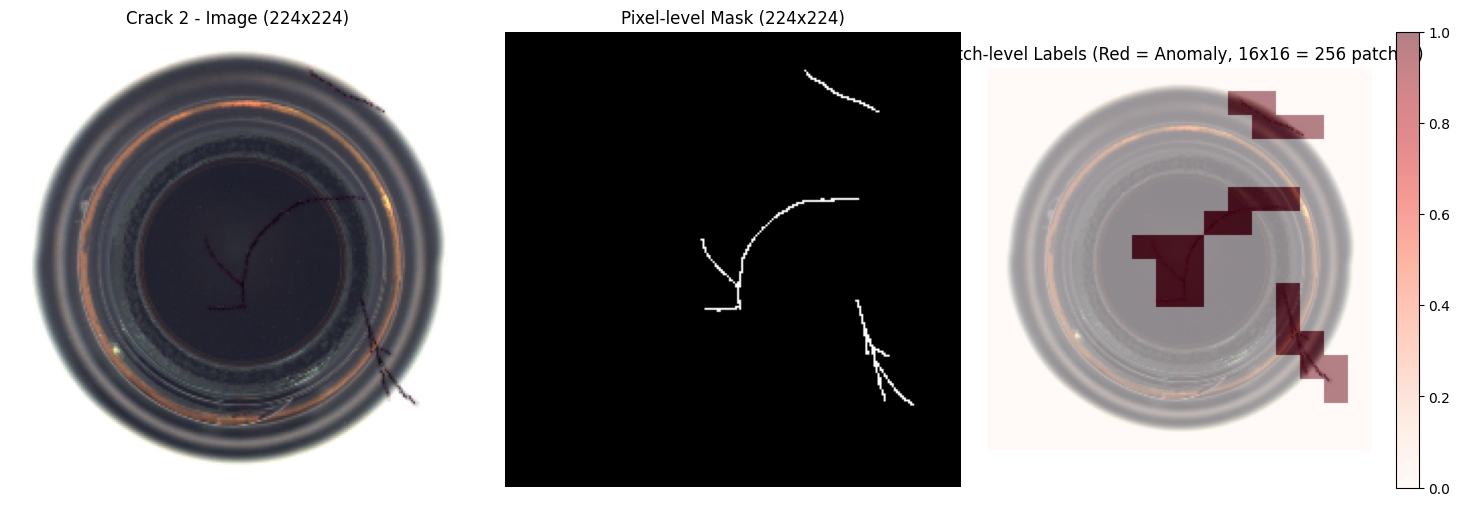

CutPaste 3: 20.0 anomalous patches out of 256 (expected 256 total patches)


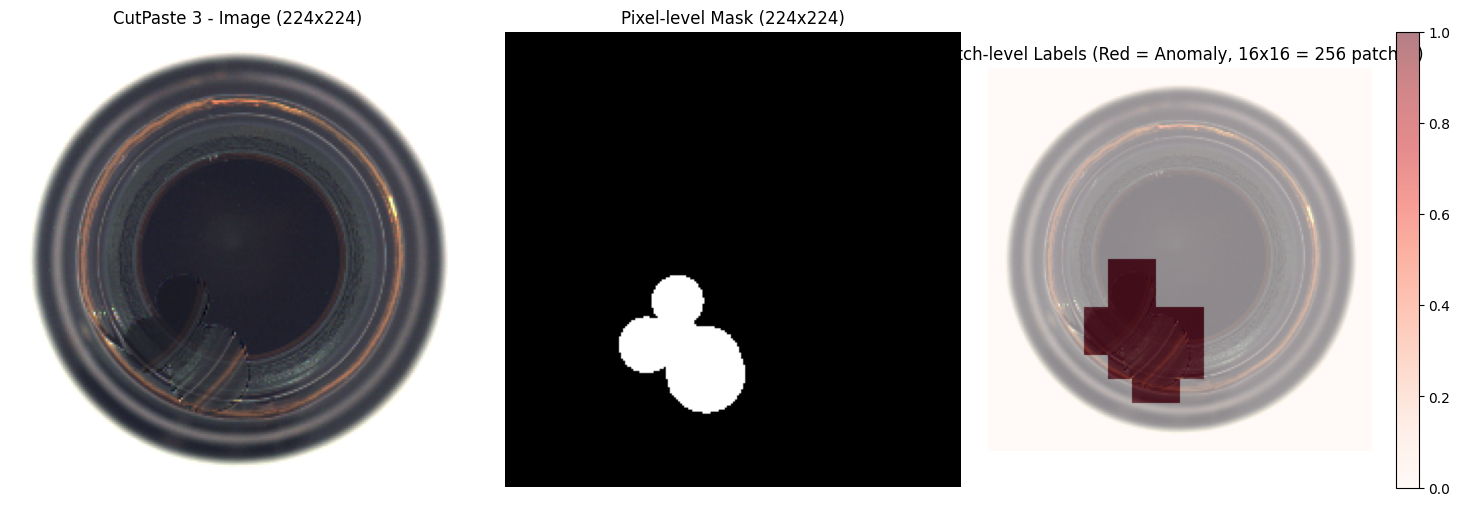

Crack 4: 26.0 anomalous patches out of 256 (expected 256 total patches)


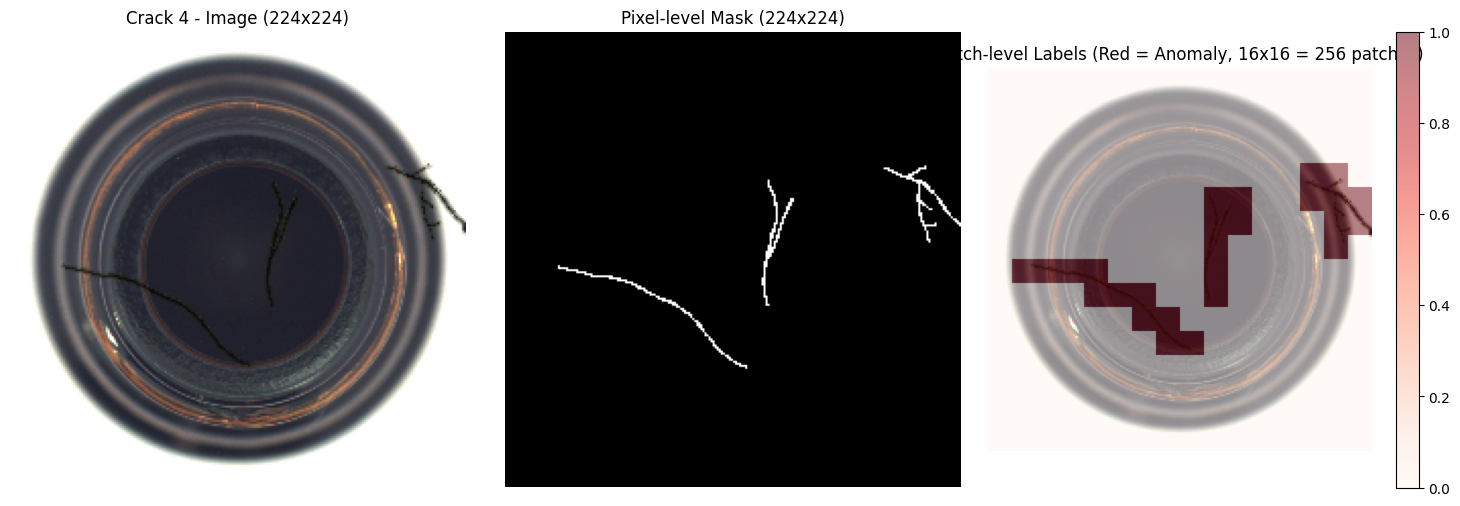

In [6]:
# Convert masks to patch-level labels and visualize
patch_size = 14  # ViT patch size
image_size = 224  # ViT image size (must match model config)

# Use the synthetic samples generated in the previous cell
if 'synthetic_samples' in locals() and len(synthetic_samples) > 0:
    # Visualize patch labels for first few samples
    num_to_show = min(4, len(synthetic_samples))
    
    for idx in range(num_to_show):
        sample = synthetic_samples[idx]
        image = sample["image"]
        mask = sample["mask"]
        method = sample["method"]
        
        # Resize mask to 224x224 to match ViT input size (critical for consistency!)
        mask_resized = cv2.resize(mask, (image_size, image_size), interpolation=cv2.INTER_NEAREST)
        
        # Convert mask to patch-level labels (now using correct dimensions)
        patch_labels = mask_to_patch_labels(mask_resized, patch_size=patch_size)
        
        expected_patches = (image_size // patch_size) ** 2
        print(f"{method} {idx+1}: {patch_labels.sum().item()} anomalous patches out of {len(patch_labels)} (expected {expected_patches} total patches)")
        
        # Visualize patch labels
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Resize image to 224x224 for consistency
        image_resized = cv2.resize(image, (image_size, image_size))
        
        # Original image
        axes[0].imshow(image_resized)
        axes[0].set_title(f"{method} {idx+1} - Image ({image_size}x{image_size})")
        axes[0].axis("off")
        
        # Pixel mask (resized)
        axes[1].imshow(mask_resized, cmap="gray")
        axes[1].set_title(f"Pixel-level Mask ({image_size}x{image_size})")
        axes[1].axis("off")
        
        # Patch labels (upsampled to image size)
        grid_size = int(np.sqrt(len(patch_labels)))
        patch_grid = patch_labels.reshape(grid_size, grid_size).numpy()
        patch_upsampled = cv2.resize(patch_grid, (image_size, image_size), interpolation=cv2.INTER_NEAREST)
        
        axes[2].imshow(image_resized)
        im = axes[2].imshow(patch_upsampled, alpha=0.5, cmap="Reds")
        axes[2].set_title(f"Patch-level Labels (Red = Anomaly, {grid_size}x{grid_size} = {len(patch_labels)} patches)")
        axes[2].axis("off")
        plt.colorbar(im, ax=axes[2])
        
        plt.tight_layout()
        plt.show()
else:
    print("Please run the synthetic anomaly generation cell first to create synthetic_samples")


## 6. Training Data with 80/20 Normal/Synthetic Split


Using synthetic method: cutpaste
Training dataset size: 209
Expected: ~167 normal, ~41 synthetic


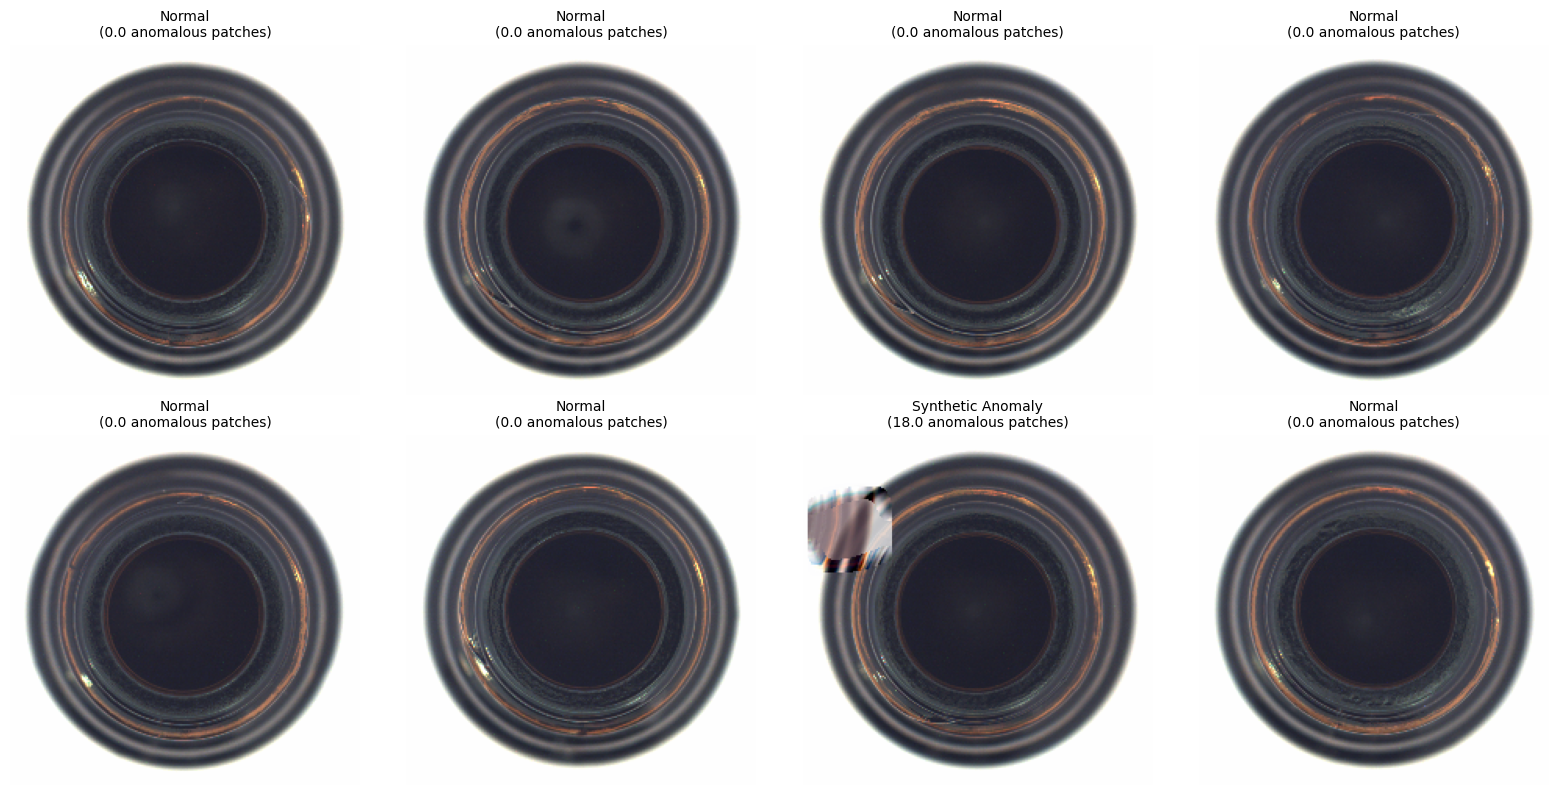

Batch statistics:
  Normal: 7/8 (87.5%)
  Synthetic: 1/8 (12.5%)


In [15]:
# Create training dataset with synthetic anomalies (80% normal, 20% synthetic)
# Get available methods for this category
available_methods = get_methods_for_category(category)
print(f"Using synthetic method: {available_methods[0] if available_methods else 'cutpaste'}")

train_dataset = MVTecDataset(
    root=root,
    category=category,
    split="train",
    image_size=image_size,
    synthetic_method=available_methods[0] if available_methods else "cutpaste",  # Must specify a method, not None
    synthetic_prob=synthetic_prob,  # 0.2 = 20% synthetic
)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Expected: ~{int(len(train_dataset) * (1 - synthetic_prob))} normal, "
      f"~{int(len(train_dataset) * synthetic_prob)} synthetic")

# Sample a batch and visualize
loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
batch = next(iter(loader))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(min(8, len(batch["image"]))):
    image = batch["image"][i]
    label = batch["label"][i].item()  # ensure int
    patch_labels = batch["patch_labels"][i]
    
    # Convert to numpy with denormalization
    image_np = image.permute(1, 2, 0).cpu().numpy()
    # Denormalize for visualization (CLIP normalization stats)
    mean = np.array([0.48145466, 0.4578275, 0.40821073])
    std = np.array([0.26862954, 0.26130258, 0.27577711])
    image_np = image_np * std + mean
    image_np = np.clip(image_np, 0, 1)
    
    axes[i].imshow(image_np)
    title = "Normal" if label == 0 else "Synthetic Anomaly"
    title += f"\n({patch_labels.sum().item()} anomalous patches)"  # corrected f-string
    axes[i].set_title(title, fontsize=10)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# Count normal vs synthetic
labels_tensor = batch["label"]
normal_count = (labels_tensor == 0).sum().item()
synthetic_count = (labels_tensor == 1).sum().item()
print("Batch statistics:")
print(f"  Normal: {normal_count}/{len(labels_tensor)} ({100*normal_count/len(labels_tensor):.1f}%)")
print(f"  Synthetic: {synthetic_count}/{len(labels_tensor)} ({100*synthetic_count/len(labels_tensor):.1f}%)")


## 7. Compare Synthetic vs Real Test Anomalies


In [ ]:
# Ensure training dataset is loaded (for comparison)
if 'train_dataset' not in locals():
    available_methods = get_methods_for_category(category)
    train_dataset = MVTecDataset(
        root=root,
        category=category,
        split="train",
        image_size=image_size,
        synthetic_method=available_methods[0] if available_methods else "cutpaste",
        synthetic_prob=synthetic_prob,
    )

# Load test dataset (contains real anomalies)
test_dataset = MVTecDataset(
    root=root,
    category=category,
    split="test",
    image_size=image_size,
    synthetic_method=None,
    synthetic_prob=0.0,
)

print(f"Test dataset size: {len(test_dataset)}")

# Get some real anomalous samples
anomalous_samples = []
for i in range(len(test_dataset)):
    sample = test_dataset[i]
    if sample["label"] == 1:  # Anomaly (label is already an int)
        anomalous_samples.append((i, sample))
    if len(anomalous_samples) >= 4:
        break

# Get some synthetic samples
synthetic_samples = []
for i in range(min(20, len(train_dataset))):
    sample = train_dataset[i]
    if sample["label"] == 1:  # Synthetic anomaly (label is already an int)
        synthetic_samples.append((i, sample))
    if len(synthetic_samples) >= 4:
        break

# Visualize comparison
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Real anomalies (top row)
for idx, (i, sample) in enumerate(anomalous_samples):
    image = sample["image"]
    image_np = image.permute(1, 2, 0).cpu().numpy()
    # Denormalize for visualization (CLIP normalization stats)
    mean = np.array([0.48145466, 0.4578275, 0.40821073])
    std = np.array([0.26862954, 0.26130258, 0.27577711])
    image_np = image_np * std + mean
    image_np = np.clip(image_np, 0, 1)
    
    axes[0, idx].imshow(image_np)
    axes[0, idx].set_title(f"Real Test Anomaly {idx+1}", fontsize=10)
    axes[0, idx].axis("off")

# Synthetic anomalies (bottom row)
for idx, (i, sample) in enumerate(synthetic_samples):
    image = sample["image"]
    image_np = image.permute(1, 2, 0).cpu().numpy()
    # Denormalize for visualization (CLIP normalization stats)
    mean = np.array([0.48145466, 0.4578275, 0.40821073])
    std = np.array([0.26862954, 0.26130258, 0.27577711])
    image_np = image_np * std + mean
    image_np = np.clip(image_np, 0, 1)
    
    axes[1, idx].imshow(image_np)
    axes[1, idx].set_title(f"Synthetic Anomaly {idx+1}", fontsize=10)
    axes[1, idx].axis("off")

plt.suptitle("Comparison: Real Test Anomalies (top) vs Synthetic Anomalies (bottom)", fontsize=12)
plt.tight_layout()
plt.show()

print("\nObservation: Compare the visual similarity between synthetic and real anomalies.")
print("Synthetic anomalies should be diverse enough to help the model generalize.")


## 8. Model Inference and Heatmap Visualization


In [ ]:
# Load model (if checkpoint exists)
import os
from models.spade import SPADE

checkpoint_dir = Path.cwd().parent / "checkpoints"
checkpoint_files = list(checkpoint_dir.glob("*.pt")) if checkpoint_dir.exists() else []

if checkpoint_files:
    # Load latest checkpoint
    latest_checkpoint = max(checkpoint_files, key=lambda p: p.stat().st_mtime)
    print(f"Loading checkpoint: {latest_checkpoint}")
    
    # Load config
    with open(Path.cwd().parent / "config" / "model.yaml") as f:
        model_cfg = yaml.safe_load(f)
    
    # Initialize model
    model = SPADE(
        blip2_model_name=model_cfg["blip2"]["model_name"],
        patch_head_hidden=model_cfg["patch_head"]["hidden_dim"],
        patch_head_dropout=model_cfg["patch_head"]["dropout"],
        llm_embed_dim=model_cfg["projection"]["output_dim"],
    ).to(device)
    
    # Load checkpoint
    checkpoint = torch.load(latest_checkpoint, map_location=device)
    if "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"], strict=False)
    else:
        model.load_state_dict(checkpoint, strict=False)
    
    model.eval()
    print("Model loaded successfully!")
    
    # Run inference on test samples
    test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)
    test_batch = next(iter(test_loader))
    
    images = test_batch["image"].to(device)
    labels = test_batch["label"].cpu().numpy()
    
    with torch.no_grad():
        outputs = model(images)
        patch_logits = outputs["patch_logits"]  # (B, N_patches)
        patch_probs = torch.sigmoid(patch_logits).cpu().numpy()
    
    # Visualize heatmaps
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    for i in range(min(4, len(images))):
        # Original image
        image_np = images[i].permute(1, 2, 0).cpu().numpy()
        # Denormalize for visualization (CLIP normalization stats)
        mean = np.array([0.48145466, 0.4578275, 0.40821073])
        std = np.array([0.26862954, 0.26130258, 0.27577711])
        image_np = image_np * std + mean
        image_np = np.clip(image_np, 0, 1)
        image_np = np.clip(image_np, 0, 1)
        
        # Heatmap
        heatmap = patches_to_heatmap(
            torch.tensor(patch_probs[i]),
            image_size=image_size,
            patch_size=14,
        )
        
        # Overlay
        overlay = overlay_heatmap((image_np * 255).astype(np.uint8), heatmap, alpha=0.4)
        
        # Original
        axes[0, i].imshow(image_np)
        axes[0, i].set_title(f"Image {i+1} (Label: {'Anomaly' if labels[i] == 1 else 'Normal'})")
        axes[0, i].axis("off")
        
        # Heatmap overlay
        axes[1, i].imshow(overlay / 255.0)
        axes[1, i].set_title(f"Anomaly Heatmap (Max: {patch_probs[i].max():.3f})")
        axes[1, i].axis("off")
    
    plt.tight_layout()
    plt.show()
    
else:
    print("No checkpoint found. Train the model first using train.py")


## 9. Detailed Patch-Level Analysis


In [ ]:
# Analyze patch-level predictions vs ground truth
if checkpoint_files:
    # Get a test sample with ground truth mask
    for i in range(len(test_dataset)):
        sample = test_dataset[i]
        if sample["label"] == 1  # label is already an int and sample.get("mask") is not None:
            break
    
    # Run inference
    image = sample["image"].unsqueeze(0).to(device)
    gt_mask = sample["mask"].cpu().numpy() if "mask" in sample else None
    gt_patch_labels = sample["patch_labels"].cpu().numpy()
    
    with torch.no_grad():
        outputs = model(image)
        patch_logits = outputs["patch_logits"][0]
        patch_probs = torch.sigmoid(patch_logits).cpu().numpy()
    
    # Visualize
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Original image
    image_np = sample["image"].permute(1, 2, 0).cpu().numpy()
    # Denormalize for visualization (CLIP normalization stats)
    mean = np.array([0.48145466, 0.4578275, 0.40821073])
    std = np.array([0.26862954, 0.26130258, 0.27577711])
    image_np = image_np * std + mean
    image_np = np.clip(image_np, 0, 1)
    image_np = np.clip(image_np, 0, 1)
    axes[0, 0].imshow(image_np)
    axes[0, 0].set_title("Original Image")
    axes[0, 0].axis("off")
    
    # Ground truth mask
    if gt_mask is not None:
        axes[0, 1].imshow(gt_mask, cmap="gray")
        axes[0, 1].set_title("Ground Truth Mask")
        axes[0, 1].axis("off")
    
    # Ground truth patch labels
    grid_size = int(np.sqrt(len(gt_patch_labels)))
    gt_patch_grid = gt_patch_labels.reshape(grid_size, grid_size)
    gt_patch_upsampled = cv2.resize(gt_patch_grid, (image_size, image_size), interpolation=cv2.INTER_NEAREST)
    axes[0, 2].imshow(image_np)
    axes[0, 2].imshow(gt_patch_upsampled, alpha=0.5, cmap="Reds")
    axes[0, 2].set_title(f"GT Patch Labels ({gt_patch_labels.sum():.0f} anomalous)")
    axes[0, 2].axis("off")
    
    # Predicted heatmap
    heatmap = patches_to_heatmap(torch.tensor(patch_probs), image_size=image_size, patch_size=14)
    axes[1, 0].imshow(heatmap, cmap="jet")
    axes[1, 0].set_title(f"Predicted Heatmap (Max: {patch_probs.max():.3f})")
    axes[1, 0].axis("off")
    
    # Overlay
    overlay = overlay_heatmap((image_np * 255).astype(np.uint8), heatmap, alpha=0.4)
    axes[1, 1].imshow(overlay / 255.0)
    axes[1, 1].set_title("Heatmap Overlay")
    axes[1, 1].axis("off")
    
    # Predicted patch labels (thresholded)
    pred_patch_labels = (patch_probs > 0.5).astype(float)
    pred_patch_grid = pred_patch_labels.reshape(grid_size, grid_size)
    pred_patch_upsampled = cv2.resize(pred_patch_grid, (image_size, image_size), interpolation=cv2.INTER_NEAREST)
    axes[1, 2].imshow(image_np)
    axes[1, 2].imshow(pred_patch_upsampled, alpha=0.5, cmap="Reds")
    axes[1, 2].set_title(f"Predicted Patches ({pred_patch_labels.sum():.0f} anomalous)")
    axes[1, 2].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nPatch-level Statistics:")
    print(f"  Ground truth anomalous patches: {gt_patch_labels.sum():.0f}/{len(gt_patch_labels)}")
    print(f"  Predicted anomalous patches (threshold=0.5): {pred_patch_labels.sum():.0f}/{len(patch_probs)}")
    print(f"  Max predicted probability: {patch_probs.max():.3f}")
    print(f"  Mean predicted probability: {patch_probs.mean():.3f}")
else:
    print("No checkpoint found. Train the model first.")


## 10. Training Data Statistics


In [ ]:
# Analyze training data distribution
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

normal_count = 0
synthetic_count = 0
total_patches_normal = 0
total_patches_synthetic = 0

for batch in train_loader:
    labels = batch["label"].numpy()
    patch_labels = batch["patch_labels"]
    
    normal_mask = labels == 0
    synthetic_mask = labels == 1
    
    normal_count += normal_mask.sum()
    synthetic_count += synthetic_mask.sum()
    
    total_patches_normal += patch_labels[normal_mask].sum().item()
    total_patches_synthetic += patch_labels[synthetic_mask].sum().item()

print(f"Training Data Statistics:")
print(f"  Total samples: {len(train_dataset)}")
print(f"  Normal samples: {normal_count} ({100*normal_count/len(train_dataset):.1f}%)")
print(f"  Synthetic anomaly samples: {synthetic_count} ({100*synthetic_count/len(train_dataset):.1f}%)")
print(f"\nPatch-level:")
print(f"  Total anomalous patches (synthetic): {total_patches_synthetic}")
print(f"  Average anomalous patches per synthetic sample: {total_patches_synthetic/max(synthetic_count, 1):.1f}")
print(f"\nExpected ratio: ~{100*(1-synthetic_prob):.0f}% normal / ~{100*synthetic_prob:.0f}% synthetic")
